# Seleção de Meta-Features com Algoritmos Genéticos em Meta-Learning

Este notebook implementa um pipeline completo de meta-aprendizado para recomendação de algoritmos de classificação usando datasets reais do OpenML.

Além do pipeline principal, esta versão inclui **checkpointing em disco** para evitar recomputar as etapas mais pesadas a cada execução.

## 0. Instalação opcional de dependências

In [2]:
pip install -U openml pandas scikit-learn joblib seaborn matplotlib pymfe pygad


[notice] A new release of pip is available: 24.2 -> 26.1.1
[notice] To update, run: python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## 1. Imports e configuração global

In [25]:
# Bibliotecas padrão para sistema de arquivos, serialização e utilidades gerais.
import os
import re
import json
import random
import pickle
import warnings
from pathlib import Path
from collections import Counter
from dataclasses import dataclass
from typing import Dict, List, Optional, Tuple

# Bibliotecas principais para computação numérica, datasets, visualização e GA.
import numpy as np
import openml
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pygad

# Ferramentas de paralelismo, meta-features e modelagem com scikit-learn.
from joblib import Parallel, delayed
from pymfe.mfe import MFE
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import ExtraTreesClassifier, GradientBoostingClassifier, RandomForestClassifier
from sklearn.feature_selection import VarianceThreshold
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import KFold, StratifiedKFold, cross_val_score
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

# Reduz ruído visual na execução e define o tema base dos gráficos.
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

# Semente global para reproduzir divisões, modelos e busca heurística.
RANDOM_STATE = 42
TARGET_DATASETS = 500
OPENML_SAMPLE_CAP = 650
N_JOBS = max(1, (os.cpu_count() or 2) - 1)

# Diretórios usados para persistir artefatos intermediários e resultados.
PROJECT_ROOT = Path.cwd()
CACHE_DIR = PROJECT_ROOT / "artifacts_meta_learning"
DATASETS_DIR = CACHE_DIR / "datasets"
META_DIR = CACHE_DIR / "meta"
RESULTS_DIR = CACHE_DIR / "results"
INTERMEDIATE_TABLES_DIR = PROJECT_ROOT / "intermidiate_tables_csv"
for folder in [CACHE_DIR, DATASETS_DIR, META_DIR, RESULTS_DIR, INTERMEDIATE_TABLES_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

MPL_TMP = os.path.join(os.getcwd(), ".mplconfig")
os.makedirs(MPL_TMP, exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", MPL_TMP)

np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

print(f"N_JOBS configurado para: {N_JOBS}")
print(f"Cache local: {CACHE_DIR}")

N_JOBS configurado para: 7
Cache local: /Users/rafaelribeiro/GitProjects/meta-learning-article/artifacts_meta_learning


## 2. Configurações experimentais

In [26]:
# Conjunto de algoritmos candidatos no nível-base.
# O melhor deles, por dataset, vira a meta-label do problema.
BASE_MODELS = {
    "DecisionTree": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "SVC": SVC(gamma="scale", random_state=RANDOM_STATE),
    "KNN": KNeighborsClassifier(),
    "LogisticRegression": LogisticRegression(max_iter=1500, solver="lbfgs", random_state=RANDOM_STATE),
    "ExtraTrees": ExtraTreesClassifier(n_estimators=250, random_state=RANDOM_STATE, n_jobs=1),
    "GradientBoosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
    "GaussianNB": GaussianNB(),
}

# Meta-modelo fixo usado tanto no fitness do GA quanto nas comparações finais.
META_MODEL = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=1,
    random_state=RANDOM_STATE,
    n_jobs=1,
)

# CV externa: mede generalização do meta-modelo em datasets nunca vistos.
OUTER_CV = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
INNER_META_CV = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
BASE_CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Hiperparâmetros do Algoritmo Genético.
# A configuração busca equilíbrio entre custo computacional e qualidade da busca.
GA_CONFIG = {
    "num_generations": 30,
    "sol_per_pop": 20,
    "num_parents_mating": 8,
    "parent_selection_type": "sss",
    "keep_parents": 4,
    "crossover_type": "single_point",
    "mutation_type": "adaptive",
    "mutation_probability": [0.20, 0.05],
    "gene_space": [0, 1],
    "suppress_warnings": True,
    "stop_criteria": ["saturate_8"],
}

# Penalização por número de meta-features escolhidas para incentivar soluções compactas.
GA_PENALTY_ALPHA = 0.03
META_FEATURE_GROUPS = ["general", "statistical", "info-theory", "landmarking"]

## 3. Utilitários de cache

Cada etapa pesada salva seus artefatos em disco. Nas execuções seguintes, o notebook tenta carregar do cache automaticamente.

In [27]:
# Funções auxiliares para persistir artefatos intermediários.
# Isso evita recomputar etapas pesadas em execuções futuras.
def save_pickle(obj, path: Path) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("wb") as f:
        pickle.dump(obj, f)


def load_pickle(path: Path):
    with path.open("rb") as f:
        return pickle.load(f)


def save_json(obj, path: Path) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("w", encoding="utf-8") as f:
        json.dump(obj, f, ensure_ascii=False, indent=2)


def load_json(path: Path):
    with path.open("r", encoding="utf-8") as f:
        return json.load(f)


def save_dataframe(df: pd.DataFrame, path: Path) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    df.to_pickle(path)


def load_dataframe(path: Path) -> pd.DataFrame:
    return pd.read_pickle(path)


# Nomes numerados e descritivos para facilitar auditoria dos blocos do notebook.
CATALOG_PATH = CACHE_DIR / "01_openml_catalog_filtered_and_deduplicated.pkl"
DATASETS_PATH = DATASETS_DIR / "02_real_openml_datasets_downloaded_and_validated.pkl"
BASE_RESULTS_PATH = META_DIR / "03_base_level_model_evaluation_results.pkl"
BASE_RESULTS_DF_PATH = META_DIR / "03_base_level_model_evaluation_results_dataframe.pkl"
META_Y_PATH = META_DIR / "04_meta_labels_best_base_learner_per_dataset.pkl"
META_X_PATH = META_DIR / "05_meta_features_matrix_extracted_with_pymfe.pkl"
OUTER_RESULTS_PATH = RESULTS_DIR / "06_outer_cv_ga_feature_selection_evaluation_results.pkl"
TOP_FEATURES_COUNTER_PATH = RESULTS_DIR / "07_ga_selected_meta_feature_frequency_counter.pkl"
FIRST_FOLD_HISTORY_PATH = RESULTS_DIR / "08_ga_convergence_history_first_outer_fold.pkl"

## 4. Seleção de datasets reais no OpenML

In [28]:
# Normaliza nomes para identificar versões diferentes do mesmo dataset.
def normalize_name(name: object) -> str:
    if pd.isna(name):
        return "unknown"
    name = str(name).lower()
    name = re.sub(r"[_\- ]v\d+", "", name)
    name = re.sub(r"[^a-z0-9]+", "_", name)
    name = re.sub(r"_+", "_", name)
    return name.strip("_")


# Monta um catálogo filtrado de candidatos do OpenML.
# A deduplicação semântica evita manter múltiplas versões do mesmo problema.
def build_openml_catalog(target_size: int, sample_cap: int, seed: int) -> pd.DataFrame:
    print("Loading OpenML catalog...")
    df = openml.datasets.list_datasets(output_format="dataframe")

    required_columns = [
        "did", "name", "version", "NumberOfInstances", "NumberOfFeatures", "NumberOfClasses", "MinorityClassSize"
    ]
    df = df[required_columns].copy()

    df = df[
        (df["NumberOfInstances"] >= 200)
        & (df["NumberOfInstances"] <= 10000)
        & (df["NumberOfFeatures"] >= 5)
        & (df["NumberOfFeatures"] <= 100)
        & (df["NumberOfClasses"].between(2, 10))
        & (df["MinorityClassSize"] >= 20)
    ].copy()

    df = df[~df["name"].str.contains("FOREX", case=False, na=False)].copy()
    df["normalized_name"] = df["name"].apply(normalize_name)
    df = df.drop_duplicates(subset=["did"])
    df = df.sort_values("version", ascending=False).drop_duplicates(subset=["normalized_name"])

    if len(df) > sample_cap:
        df = df.sample(n=sample_cap, random_state=seed)

    return df.sort_values(by=["NumberOfInstances", "NumberOfFeatures"]).reset_index(drop=True)


# Reaproveita o catálogo salvo se ele já existir em disco.
if CATALOG_PATH.exists():
    catalog_df = load_dataframe(CATALOG_PATH)
    print(f"Catalog carregado do cache: {CATALOG_PATH}")
else:
    catalog_df = build_openml_catalog(TARGET_DATASETS, OPENML_SAMPLE_CAP, RANDOM_STATE)
    save_dataframe(catalog_df, CATALOG_PATH)
    print(f"Catalog salvo em: {CATALOG_PATH}")

print(f"Candidatos no catálogo: {len(catalog_df)}")
catalog_df.head()

Catalog carregado do cache: /Users/rafaelribeiro/GitProjects/meta-learning-article/artifacts_meta_learning/01_openml_catalog_filtered_and_deduplicated.pkl
Candidatos no catálogo: 650


,did,name,version,NumberOfInstances,NumberOfFeatures,NumberOfClasses,MinorityClassSize,normalized_name
0,446,prnn_crabs,1,200.0,8.0,2.0,100.0,prnn_crabs
1,721,pwLinear,2,200.0,11.0,2.0,97.0,pwlinear
2,43786,Zombies-Apocalypse,1,200.0,13.0,2.0,79.0,zombies_apocalypse
3,46844,Predicting_Risk_Factors_of_Chronic_Kidney_Disease,2,200.0,29.0,2.0,72.0,predicting_risk_factors_of_chronic_kidney_disease
4,42172,regime_alimentaire,1,202.0,20.0,2.0,41.0,regime_alimentaire


## 5. Download e validação dos datasets

Os datasets válidos são serializados em disco. Se já existirem, você não precisa baixar tudo novamente.

In [29]:
# Garante que o alvo seja tratado como uma Series simples de classificação.
def _coerce_target(y: object) -> pd.Series:
    if isinstance(y, pd.Series):
        return y.reset_index(drop=True)
    if isinstance(y, pd.DataFrame):
        if y.shape[1] != 1:
            raise ValueError("Target multirrótulo não suportado neste experimento.")
        return y.iloc[:, 0].reset_index(drop=True)
    return pd.Series(y).reset_index(drop=True)


# Padroniza o dataset de entrada como DataFrame com nomes de colunas em texto.
def _sanitize_dataframe(X: object) -> pd.DataFrame:
    if isinstance(X, pd.DataFrame):
        df = X.copy()
    else:
        df = pd.DataFrame(X)
    df.columns = [str(col) for col in df.columns]
    return df.reset_index(drop=True)


# Faz o download do dataset, valida suas propriedades e devolve um dicionário padronizado.
def download_openml_dataset(row: pd.Series) -> Optional[Dict[str, object]]:
    did = int(row["did"])
    # Alguns datasets do OpenML são multi-target, quebrados ou incompatíveis com este experimento.
    try:
        dataset = openml.datasets.get_dataset(did, download_data=True)
        X, y, _, _ = dataset.get_data(dataset_format="dataframe", target=dataset.default_target_attribute)
    except Exception as exc:
        print(f"[skip] did={did} | download error: {exc}")
        return None

    try:
        X = _sanitize_dataframe(X)
        y = _coerce_target(y)
    except Exception as exc:
        print(f"[skip] did={did} | coercion error: {exc}")
        return None

    if len(X) != len(y):
        return None
    if X.shape[0] < 200 or X.shape[0] > 10000:
        return None
    if X.shape[1] < 5 or X.shape[1] > 100:
        return None

    y = y.replace([np.inf, -np.inf], np.nan)
    valid_mask = y.notna()
    X = X.loc[valid_mask].reset_index(drop=True)
    y = y.loc[valid_mask].reset_index(drop=True)

    # Mantém apenas problemas de classificação com faixa controlada de classes.
    if y.nunique() < 2 or y.nunique() > 10:
        return None
    if y.value_counts().min() < 20:
        return None

    return {
        "openml_id": did,
        "name": f"openml_{did}_{normalize_name(row['name'])}",
        "data": X,
        "target": y,
    }


# Se o cache existir, evita repetir o download; caso contrário, baixa e registra o progresso.
if DATASETS_PATH.exists():
    datasets = load_pickle(DATASETS_PATH)
    print(f"Datasets carregados do cache: {DATASETS_PATH}")
else:
    datasets = []
    for _, row in catalog_df.iterrows():
        ds = download_openml_dataset(row)
        if ds is not None:
            datasets.append(ds)
        if len(datasets) >= TARGET_DATASETS:
            break
    save_pickle(datasets, DATASETS_PATH)
    print(f"Datasets salvos em: {DATASETS_PATH}")

print(f"Datasets reais válidos: {len(datasets)}")
datasets[0]['data'].head() if datasets else None

Datasets carregados do cache: /Users/rafaelribeiro/GitProjects/meta-learning-article/artifacts_meta_learning/datasets/02_real_openml_datasets_downloaded_and_validated.pkl
Datasets reais válidos: 500


,sex,index,FL,RW,CL,CW,BD
0,Male,1,8.1,6.7,16.1,19.0,7.0
1,Male,2,8.8,7.7,18.1,20.8,7.4
2,Male,3,9.2,7.8,19.0,22.4,7.7
3,Male,4,9.6,7.9,20.1,23.1,8.2
4,Male,5,9.8,8.0,20.3,23.0,8.2


## 6. Funções auxiliares de pré-processamento

In [30]:
# Identifica quais atributos serão tratados como categóricos e quais como numéricos.
def infer_column_types(df: pd.DataFrame) -> Tuple[List[str], List[str]]:
    categorical_cols = df.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
    numeric_cols = [col for col in df.columns if col not in categorical_cols]
    return categorical_cols, numeric_cols


# Codifica o target em inteiros para compatibilidade com os modelos e com o MFE.
def encode_target(y: pd.Series) -> np.ndarray:
    y_series = pd.Series(y).astype(str).reset_index(drop=True)
    encoder = LabelEncoder()
    return encoder.fit_transform(y_series)


# Pipeline do nível-base.
# Numéricos: KNNImputer. Categóricos: imputação + one-hot encoding.
def build_base_pipeline(model) -> Pipeline:
    numeric_transformer = Pipeline(steps=[("imputer", KNNImputer(n_neighbors=5))])
    categorical_transformer = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
        ]
    )

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, lambda X: X.select_dtypes(exclude=["object", "category", "bool"]).columns),
            ("cat", categorical_transformer, lambda X: X.select_dtypes(include=["object", "category", "bool"]).columns),
        ],
        remainder="drop",
    )

    return Pipeline(steps=[("preprocessor", preprocessor), ("model", model)])


# Prepara uma versão totalmente numérica do dataset para a extração de meta-features.
# Categóricos são codificados ordinalmente apenas para uso do MFE.
def prepare_dataset_for_mfe(df: pd.DataFrame) -> np.ndarray:
    categorical_cols, numeric_cols = infer_column_types(df)
    work_df = df.copy()

    if categorical_cols:
        cat_imputer = SimpleImputer(strategy="most_frequent")
        ordinal_encoder = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
        work_df[categorical_cols] = cat_imputer.fit_transform(work_df[categorical_cols])
        work_df[categorical_cols] = ordinal_encoder.fit_transform(work_df[categorical_cols])

    if numeric_cols:
        work_df[numeric_cols] = work_df[numeric_cols].apply(pd.to_numeric, errors="coerce")

    imputed = KNNImputer(n_neighbors=5).fit_transform(work_df)
    return np.asarray(imputed, dtype=float)

## 7. Fase 1: geração da meta-label (`meta_y`)

Os resultados da avaliação dos base learners são armazenados em cache.

In [32]:
# Avalia todos os algoritmos candidatos em um dataset e retorna o melhor deles.
def evaluate_base_learners(dataset: Dict[str, object]) -> Dict[str, object]:
    X = dataset["data"]
    y = encode_target(dataset["target"])

    # Cada score médio passa a representar quão competitivo o algoritmo foi neste problema.
    scores = {}
    for name, model in BASE_MODELS.items():
        pipeline = build_base_pipeline(clone(model))
        cv_scores = cross_val_score(pipeline, X, y, cv=BASE_CV, scoring="accuracy", n_jobs=1)
        scores[name] = float(np.mean(cv_scores))

    best_model_name = max(scores, key=scores.get)
    return {"dataset_name": dataset["name"], "best_model": best_model_name, "scores": scores}


# Reaproveita o meta-target salvo caso a etapa já tenha sido concluída antes.
if BASE_RESULTS_PATH.exists() and BASE_RESULTS_DF_PATH.exists() and META_Y_PATH.exists():
    print("Base-level results encontrados no cache, carregando...")
    base_results = load_pickle(BASE_RESULTS_PATH)
    base_results_df = load_dataframe(BASE_RESULTS_DF_PATH)
    meta_y = np.array(load_pickle(META_Y_PATH))
    print(f"Base-level results carregados do cache: {BASE_RESULTS_PATH}")
else:
    print("Base-level results não encontrados no cache, avaliando base learners...")
    base_results = Parallel(n_jobs=N_JOBS, verbose=10)(
        delayed(evaluate_base_learners)(dataset) for dataset in datasets
    )
    meta_y = np.array([item["best_model"] for item in base_results])
    base_results_df = pd.DataFrame(
        [{"dataset_name": r["dataset_name"], **r["scores"], "meta_label": r["best_model"]} for r in base_results]
    )
    save_pickle(base_results, BASE_RESULTS_PATH)
    save_dataframe(base_results_df, BASE_RESULTS_DF_PATH)
    save_pickle(meta_y.tolist(), META_Y_PATH)
    print(f"Base-level results salvos em: {BASE_RESULTS_PATH}")

print(pd.Series(meta_y).value_counts())
base_results_df.head()

Base-level results encontrados no cache, carregando...
Base-level results carregados do cache: /Users/rafaelribeiro/GitProjects/meta-learning-article/artifacts_meta_learning/meta/03_base_level_model_evaluation_results.pkl
GradientBoosting      193
ExtraTrees            165
LogisticRegression     58
SVC                    51
DecisionTree           25
GaussianNB              6
KNN                     2
Name: count, dtype: int64


,dataset_name,DecisionTree,SVC,KNN,LogisticRegression,ExtraTrees,GradientBoosting,GaussianNB,meta_label
0,openml_446_prnn_crabs,0.91500,0.83500,0.93000,0.995000,0.960000,0.950000,0.625000,LogisticRegression
1,openml_721_pwlinear,0.81000,0.88500,0.83000,0.845000,0.880000,0.880000,0.845000,SVC
2,openml_43786_zombies_apocalypse,0.69000,0.70000,0.67500,0.870000,0.820000,0.765000,0.820000,LogisticRegression
3,openml_46844_predicting_risk_factors_of_chronic_kidney_disease,1.00000,1.00000,0.96000,1.000000,1.000000,1.000000,1.000000,DecisionTree
4,openml_42172_regime_alimentaire,0.92061,0.94061,0.94061,0.980122,0.856463,0.955366,0.456585,LogisticRegression


## 8. Fase 2: extração das meta-features (`meta_X`)

A matriz de meta-features também é persistida em disco.

In [33]:
# Extrai meta-features do dataset já convertido para uma representação numérica estável.
def extract_meta_features(dataset: Dict[str, object], groups: List[str]) -> Dict[str, object]:
    X_df = dataset["data"]
    y = encode_target(dataset["target"])
    X_num = prepare_dataset_for_mfe(X_df)

    # Resumos múltiplos aumentam a riqueza descritiva do meta-dataset.
    mfe = MFE(groups=groups, summary=["mean", "sd", "min", "max"])
    mfe.fit(X_num, y)
    feature_names, feature_values = mfe.extract()
    return {"dataset_name": dataset["name"], "feature_names": list(feature_names), "feature_values": list(feature_values)}


# Carrega do cache a matriz de meta-features caso ela já exista.
if META_X_PATH.exists():
    meta_X = load_dataframe(META_X_PATH)
    print(f"meta_X carregado do cache: {META_X_PATH}")
else:
    meta_feature_results = Parallel(n_jobs=N_JOBS, verbose=10)(
        delayed(extract_meta_features)(dataset, META_FEATURE_GROUPS) for dataset in datasets
    )
    reference_names = meta_feature_results[0]["feature_names"]
    for item in meta_feature_results[1:]:
        if item["feature_names"] != reference_names:
            raise ValueError("A ordem ou a quantidade de meta-features mudou entre datasets.")

    meta_X = pd.DataFrame(
        [item["feature_values"] for item in meta_feature_results],
        columns=reference_names,
        index=[item["dataset_name"] for item in meta_feature_results],
    )
    save_dataframe(meta_X, META_X_PATH)
    print(f"meta_X salvo em: {META_X_PATH}")

print("Shape de meta_X:", meta_X.shape)
meta_X.head()

meta_X carregado do cache: /Users/rafaelribeiro/GitProjects/meta-learning-article/artifacts_meta_learning/meta/05_meta_features_matrix_extracted_with_pymfe.pkl
Shape de meta_X: (500, 151)


,attr_conc.max,attr_conc.mean,attr_conc.min,attr_conc.sd,attr_ent.max,attr_ent.mean,attr_ent.min,attr_ent.sd,attr_to_inst,best_node.max,best_node.mean,best_node.min,best_node.sd,can_cor.max,can_cor.mean,can_cor.min,can_cor.sd,cat_to_num,class_conc.max,class_conc.mean,class_conc.min,class_conc.sd,class_ent,cor.max,cor.mean,cor.min,cor.sd,cov.max,cov.mean,cov.min,cov.sd,eigenvalues.max,eigenvalues.mean,eigenvalues.min,eigenvalues.sd,elite_nn.max,elite_nn.mean,elite_nn.min,elite_nn.sd,eq_num_attr,freq_class.max,freq_class.mean,freq_class.min,freq_class.sd,g_mean.max,g_mean.mean,g_mean.min,g_mean.sd,gravity,h_mean.max,h_mean.mean,h_mean.min,h_mean.sd,inst_to_attr,iq_range.max,iq_range.mean,iq_range.min,iq_range.sd,joint_ent.max,joint_ent.mean,joint_ent.min,joint_ent.sd,kurtosis.max,kurtosis.mean,kurtosis.min,kurtosis.sd,lh_trace,linear_discr.max,linear_discr.mean,linear_discr.min,linear_discr.sd,mad.max,mad.mean,mad.min,mad.sd,max.max,max.mean,max.min,max.sd,mean.max,mean.mean,mean.min,mean.sd,median.max,median.mean,median.min,median.sd,min.max,min.mean,min.min,min.sd,mut_inf.max,mut_inf.mean,mut_inf.min,mut_inf.sd,naive_bayes.max,naive_bayes.mean,naive_bayes.min,naive_bayes.sd,nr_attr,nr_bin,nr_cat,nr_class,nr_cor_attr,nr_disc,nr_inst,nr_norm,nr_num,nr_outliers,ns_ratio,num_to_cat,one_nn.max,one_nn.mean,one_nn.min,one_nn.sd,p_trace,random_node.max,random_node.mean,random_node.min,random_node.sd,range.max,range.mean,range.min,range.sd,roy_root,sd.max,sd.mean,sd.min,sd.sd,sd_ratio,skewness.max,skewness.mean,skewness.min,skewness.sd,sparsity.max,sparsity.mean,sparsity.min,sparsity.sd,t_mean.max,t_mean.mean,t_mean.min,t_mean.sd,var.max,var.mean,var.min,var.sd,w_lambda,worst_node.max,worst_node.mean,worst_node.min,worst_node.sd
openml_446_prnn_crabs,0.796862,0.340450,-1.000000e-07,0.256006,2.321928,2.132512,1.000000,0.499391,0.035000,0.8,0.545000,0.5,0.101242,0.962822,0.962822,0.962822,NaN,0.0,0.040080,0.019953,-4.000000e-08,0.016233,1.000000,0.995023,0.689424,0.000000,0.387240,105.712814,25.606580,0.000000,29.550532,335.859350,50.394825,0.050928,125.986356,0.70,0.515000,0.25,0.135503,16.383040,0.50000,0.5,0.50000,0.000000,35.511123,18.213269,0.0,12.018237,6.973567,34.544492,16.582136,0.0,11.919640,28.571429,25.0,8.585714,1.0,7.996912,3.321928,3.071473,2.000000,0.474475,-0.330401,-0.857847,-2.009975,0.574581,12.703649,1.00,1.000000,1.00,0.000000,18.5325,6.375180,0.7413,5.916484,54.6,31.157143,1.0,19.835814,36.414500,19.553143,0.500000,12.469666,36.8,19.592857,0.5,12.562127,17.1,7.514286,0.0,6.397246,0.125380,0.061039,-1.879233e-07,0.050795,1.0,0.575000,0.50,0.155009,7,1,0,2,0.714286,1,200,5.0,7,1,33.937032,NaN,1.00,0.855000,0.70,0.127911,0.927027,0.550000,0.500000,0.450000,0.023570,49.0,23.642857,1.0,16.625869,12.703649,14.467083,5.636102,0.501255,4.661979,NaN,0.025566,-0.016104,-0.098345,0.048169,0.497487,0.075935,0.001587,0.185942,36.580833,19.581905,0.500000,12.528760,209.296482,50.394825,0.251256,73.899419,0.072973,0.500000,0.500000,0.500000,0.000000
openml_721_pwlinear,0.043028,0.009696,1.987745e-05,0.008027,1.584381,1.517821,0.996463,0.183333,0.050000,1.0,0.830000,0.7,0.094868,0.785310,0.785310,0.785310,NaN,0.0,0.435356,0.060243,1.751949e-03,0.133851,0.999351,0.175343,0.059004,0.000547,0.049077,0.143518,0.042184,0.000452,0.037202,1.152723,0.707492,0.445553,0.207240,0.70,0.435000,0.00,0.213503,16.815883,0.51500,0.5,0.48500,0.021213,NaN,NaN,NaN,NaN,1.590924,NaN,NaN,NaN,NaN,20.000000,2.0,2.000000,2.0,0.000000,2.576297,2.457743,1.653830,0.285356,-1.350240,-1.558652,-1.990475,0.168693,1.609001,1.00,0.845000,0.70,0.092646,1.4826,1.334340,0.0000,0.468839,1.0,1.000000,1.0,0.000000,0.105000,-0.011000,-0.115000,0.073967,1.0,0.100000,0.0,0.316228,-1.0,-1.000000,-1.0,0.000000,0.341984,0.059429,2.458632e-03,0.106180,1.0,0.835000,0.70,0.094428,10,1,0,2,0.000000,1,200,0.0,10,0,24.540081,NaN,0.95,0.840000,0.80,0.045947,0.616712,0.600000,0.475000,0.400000,0.058926,2.0,2.000000,2.0,0.000000,1.609001,1.000050,0.839202,0.777817,0.059931,NaN,0.21830

## 9. Fases 3 e 4: validação externa + GA no conjunto de treino

Os resultados finais dos folds externos também são armazenados, incluindo histórico do primeiro fold e frequência das meta-features selecionadas.

In [35]:
# Estrutura que encapsula os transformadores ajustados apenas no treino de cada fold externo.
@dataclass
class MetaPreprocessor:
    imputer: SimpleImputer
    variance_filter: VarianceThreshold
    scaler: StandardScaler
    valid_input_columns_: np.ndarray
    selected_columns_: np.ndarray

    # Aplica ao teste exatamente as mesmas transformações aprendidas no treino.
    def transform(self, X: pd.DataFrame) -> np.ndarray:
        X_work = X.replace([np.inf, -np.inf], np.nan)
        X_work = X_work.loc[:, self.valid_input_columns_]
        X_imputed = self.imputer.transform(X_work)
        X_filtered = self.variance_filter.transform(X_imputed)
        X_scaled = self.scaler.transform(X_filtered)
        return X_scaled


# Ajusta o pré-processamento do meta-dataset sem vazamento de informação.
def fit_meta_preprocessor(X_train: pd.DataFrame) -> MetaPreprocessor:
    X_work = X_train.replace([np.inf, -np.inf], np.nan)

    # Remove meta-features completamente ausentes neste fold para evitar desalinhamento
    valid_input_columns = X_work.columns[~X_work.isna().all(axis=0)].to_numpy()
    X_work = X_work.loc[:, valid_input_columns]

    imputer = SimpleImputer(strategy="median")
    X_imputed = imputer.fit_transform(X_work)

    variance_filter = VarianceThreshold(threshold=1e-8)
    X_filtered = variance_filter.fit_transform(X_imputed)
    selected_columns = valid_input_columns[variance_filter.get_support()]

    scaler = StandardScaler()
    scaler.fit(X_filtered)

    return MetaPreprocessor(
        imputer=imputer,
        variance_filter=variance_filter,
        scaler=scaler,
        valid_input_columns_=valid_input_columns,
        selected_columns_=selected_columns,
    )


# Evita soluções inválidas do GA que zerem todas as meta-features.
def ensure_non_empty_mask(mask: np.ndarray, fallback_index: int = 0) -> np.ndarray:
    mask = mask.astype(bool)
    if mask.sum() == 0:
        mask[fallback_index] = True
    return mask


# Cria a função de fitness do GA: acurácia interna menos penalização por dimensionalidade.
def make_ga_fitness(X_train: np.ndarray, y_train: np.ndarray, alpha: float):
    n_features = X_train.shape[1]

    def fitness_func(ga_instance, solution, solution_idx):
        mask = ensure_non_empty_mask(np.array(solution, dtype=int))
        X_selected = X_train[:, mask]
        scores = cross_val_score(clone(META_MODEL), X_selected, y_train, cv=INNER_META_CV, scoring="accuracy", n_jobs=1)
        accuracy = float(np.mean(scores))
        penalty = alpha * (mask.sum() / n_features)
        return accuracy - penalty

    return fitness_func


# Executa o Algoritmo Genético e devolve a melhor máscara binária encontrada.
def run_ga_feature_selection(X_train: np.ndarray, y_train: np.ndarray, fold_seed: int):
    n_features = X_train.shape[1]
    initial_population = np.random.default_rng(fold_seed).integers(low=0, high=2, size=(GA_CONFIG['sol_per_pop'], n_features))
    history = []

    def on_generation(ga_instance):
        history.append(float(ga_instance.best_solution(pop_fitness=ga_instance.last_generation_fitness)[1]))

    ga_instance = pygad.GA(
        num_genes=n_features,
        fitness_func=make_ga_fitness(X_train, y_train, GA_PENALTY_ALPHA),
        initial_population=initial_population,
        random_seed=fold_seed,
        on_generation=on_generation,
        **GA_CONFIG,
    )
    ga_instance.run()
    best_solution, best_fitness, _ = ga_instance.best_solution()
    best_mask = ensure_non_empty_mask(np.array(best_solution, dtype=int))
    return best_mask, float(best_fitness), history


# Treina e avalia uma estratégia de seleção de meta-features no fold atual.
def evaluate_meta_strategy(X_train: np.ndarray, y_train: np.ndarray, X_test: np.ndarray, y_test: np.ndarray, mask: np.ndarray) -> float:
    mask = ensure_non_empty_mask(mask)
    model = clone(META_MODEL)
    model.fit(X_train[:, mask], y_train)
    preds = model.predict(X_test[:, mask])
    return float(accuracy_score(y_test, preds))


# Seleção de referência baseada na importância nativa de features da Random Forest.
def get_topk_importance_mask(X_train: np.ndarray, y_train: np.ndarray, k: int) -> Tuple[np.ndarray, np.ndarray]:
    model = clone(META_MODEL)
    model.fit(X_train, y_train)
    importances = model.feature_importances_
    topk_idx = np.argsort(importances)[::-1][:k]
    mask = np.zeros(X_train.shape[1], dtype=bool)
    mask[topk_idx] = True
    return mask, importances


# Baseline aleatório com o mesmo orçamento de atributos escolhido pelo GA.
def get_random_mask(n_features: int, k: int, seed: int) -> np.ndarray:
    rng = np.random.default_rng(seed)
    chosen = rng.choice(np.arange(n_features), size=max(1, k), replace=False)
    mask = np.zeros(n_features, dtype=bool)
    mask[chosen] = True
    return mask

## 10. Fase 5: avaliação comparativa

In [38]:
# Se a etapa final já tiver sido executada antes, reaproveita os resultados do cache.
if OUTER_RESULTS_PATH.exists() and TOP_FEATURES_COUNTER_PATH.exists() and FIRST_FOLD_HISTORY_PATH.exists():
    results_df = load_dataframe(OUTER_RESULTS_PATH)
    selected_feature_counter = load_pickle(TOP_FEATURES_COUNTER_PATH)
    first_fold_ga_history = load_pickle(FIRST_FOLD_HISTORY_PATH)
    print(f"Resultados externos carregados do cache: {OUTER_RESULTS_PATH}")
else:
    print("Resultados externos não encontrados no cache, executando avaliação com GA...")
    outer_fold_results = []
    selected_feature_counter = Counter()
    first_fold_ga_history = None

    # Cada fold externo simula a generalização do meta-modelo para novos datasets.
    for fold_idx, (train_idx, test_idx) in enumerate(OUTER_CV.split(meta_X, meta_y), start=1):
        print(f"Processando fold externo {fold_idx}/5...")
        X_train_df = meta_X.iloc[train_idx].copy()
        X_test_df = meta_X.iloc[test_idx].copy()
        y_train = meta_y[train_idx]
        y_test = meta_y[test_idx]

        preprocessor = fit_meta_preprocessor(X_train_df)
        X_train = preprocessor.transform(X_train_df)
        X_test = preprocessor.transform(X_test_df)
        surviving_feature_names = preprocessor.selected_columns_

        # Baseline = usa todas as meta-features restantes após o pré-processamento.
        baseline_mask = np.ones(X_train.shape[1], dtype=bool)
        ga_mask, ga_fitness, ga_history = run_ga_feature_selection(X_train, y_train, fold_seed=RANDOM_STATE + fold_idx)

        if first_fold_ga_history is None:
            first_fold_ga_history = ga_history.copy()

        # As demais estratégias usam o mesmo tamanho K escolhido pela solução do GA.
        k_selected = int(ga_mask.sum())
        random_mask = get_random_mask(X_train.shape[1], k_selected, seed=RANDOM_STATE + 1000 + fold_idx)
        importance_mask, _ = get_topk_importance_mask(X_train, y_train, k_selected)

        baseline_acc = evaluate_meta_strategy(X_train, y_train, X_test, y_test, baseline_mask)
        ga_acc = evaluate_meta_strategy(X_train, y_train, X_test, y_test, ga_mask)
        random_acc = evaluate_meta_strategy(X_train, y_train, X_test, y_test, random_mask)
        importance_acc = evaluate_meta_strategy(X_train, y_train, X_test, y_test, importance_mask)

        selected_names = surviving_feature_names[ga_mask]
        selected_feature_counter.update(selected_names)

        outer_fold_results.append({
            'fold': fold_idx,
            'n_features_total': int(X_train.shape[1]),
            'n_features_ga': k_selected,
            'reduction_pct': float(100 * (1 - (k_selected / X_train.shape[1]))),
            'ga_fitness': ga_fitness,
            'baseline_accuracy': baseline_acc,
            'ga_accuracy': ga_acc,
            'random_accuracy': random_acc,
            'importance_accuracy': importance_acc,
        })

    results_df = pd.DataFrame(outer_fold_results)
    save_dataframe(results_df, OUTER_RESULTS_PATH)
    save_pickle(selected_feature_counter, TOP_FEATURES_COUNTER_PATH)
    save_pickle(first_fold_ga_history, FIRST_FOLD_HISTORY_PATH)
    print(f"Resultados externos salvos em: {OUTER_RESULTS_PATH}")

results_df

Resultados externos carregados do cache: /Users/rafaelribeiro/GitProjects/meta-learning-article/artifacts_meta_learning/results/06_outer_cv_ga_feature_selection_evaluation_results.pkl


,fold,n_features_total,n_features_ga,reduction_pct,ga_fitness,baseline_accuracy,ga_accuracy,random_accuracy,importance_accuracy
0,1,148,60,59.459459,0.652915,0.66,0.69,0.64,0.67
1,2,148,76,48.648649,0.629603,0.69,0.63,0.66,0.68
2,3,148,70,52.702703,0.650832,0.70,0.69,0.69,0.70
3,4,148,62,58.108108,0.642540,0.67,0.67,0.68,0.68
4,5,148,72,51.351351,0.650445,0.61,0.57,0.61,0.60


## 11. Tabela consolidada de desempenho

In [39]:
# Consolida o desempenho médio das quatro estratégias comparadas.
summary_table = pd.DataFrame(
    {
        'Abordagem': ['Baseline', 'GA', 'Random Feature Selection', 'Feature Importance'],
        'Acurácia média no meta-teste': [
            results_df['baseline_accuracy'].mean(),
            results_df['ga_accuracy'].mean(),
            results_df['random_accuracy'].mean(),
            results_df['importance_accuracy'].mean(),
        ],
        'Desvio padrão': [
            results_df['baseline_accuracy'].std(),
            results_df['ga_accuracy'].std(),
            results_df['random_accuracy'].std(),
            results_df['importance_accuracy'].std(),
        ],
    }
)
summary_table = summary_table.sort_values('Acurácia média no meta-teste', ascending=False).reset_index(drop=True)
summary_table.style.format({'Acurácia média no meta-teste': '{:.4f}', 'Desvio padrão': '{:.4f}'})

,Abordagem,Acurácia média no meta-teste,Desvio padrão
0,Feature Importance,0.6660,0.0385
1,Baseline,0.6660,0.0351
2,Random Feature Selection,0.6560,0.0321
3,GA,0.6500,0.0510


## 12. Redução média de dimensionalidade promovida pelo GA

In [40]:
# Mede o quanto o GA conseguiu reduzir a dimensionalidade do meta-dataset.
avg_reduction = results_df['reduction_pct'].mean()
avg_features_total = results_df['n_features_total'].mean()
avg_features_ga = results_df['n_features_ga'].mean()
print(f'Número médio de meta-features após pré-processamento: {avg_features_total:.2f}')
print(f'Número médio de meta-features selecionadas pelo GA: {avg_features_ga:.2f}')
print(f'Redução percentual média: {avg_reduction:.2f}%')

Número médio de meta-features após pré-processamento: 148.00
Número médio de meta-features selecionadas pelo GA: 68.00
Redução percentual média: 54.05%


## 13. Curva de convergência do GA no primeiro fold

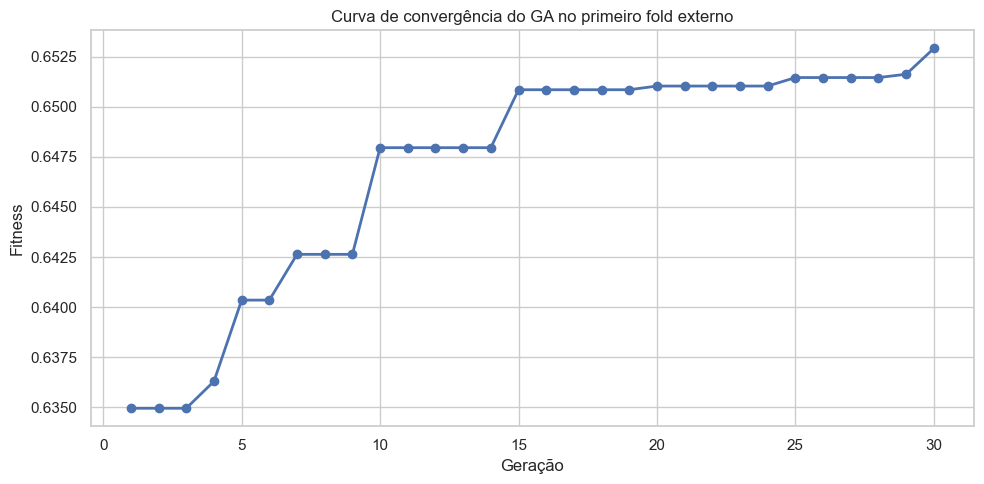

In [41]:
# Curva de convergência do GA para inspecionar ganho de fitness ao longo das gerações.
plt.figure(figsize=(10, 5))
plt.plot(np.arange(1, len(first_fold_ga_history) + 1), first_fold_ga_history, marker='o', linewidth=2)
plt.title('Curva de convergência do GA no primeiro fold externo')
plt.xlabel('Geração')
plt.ylabel('Fitness')
plt.tight_layout()
plt.show()

## 14. Meta-features mais recorrentes nas soluções do GA

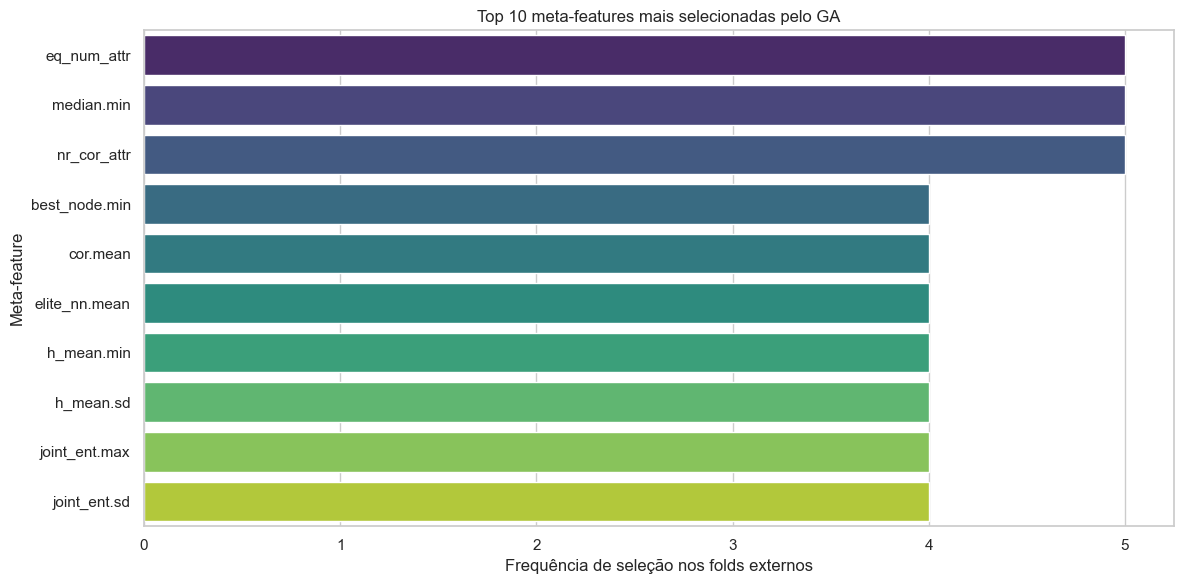

,meta_feature,frequencia
0,eq_num_attr,5
1,median.min,5
2,nr_cor_attr,5
3,best_node.min,4
4,cor.mean,4
5,elite_nn.mean,4
6,h_mean.min,4
7,h_mean.sd,4
8,joint_ent.max,4
9,joint_ent.sd,4


In [42]:
# Conta quais meta-features aparecem com maior frequência nas melhores soluções do GA.
top_features_df = pd.DataFrame(selected_feature_counter.most_common(10), columns=['meta_feature', 'frequencia'])
plt.figure(figsize=(12, 6))
sns.barplot(data=top_features_df, x='frequencia', y='meta_feature', palette='viridis')
plt.title('Top 10 meta-features mais selecionadas pelo GA')
plt.xlabel('Frequência de seleção nos folds externos')
plt.ylabel('Meta-feature')
plt.tight_layout()
plt.show()
top_features_df

## 15. Visualização completa das tabelas importantes

Este bloco imprime, por inteiro, as principais tabelas geradas ao longo do pipeline para facilitar inspeção manual no notebook.

In [ ]:
import pandas as pd
import openpyxl

# Ajusta o pandas para mostrar todas as linhas e colunas durante esta inspeção.
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', None)

# Também salva as tabelas principais em arquivos Excel para consulta fora do notebook.
catalog_df.to_excel(INTERMEDIATE_TABLES_DIR / '01_openml_catalog_filtered_and_deduplicated.csv', index=False)
base_results_df.to_excel(INTERMEDIATE_TABLES_DIR / '02_base_level_model_evaluation_results.csv', index=False)
meta_X.to_excel(INTERMEDIATE_TABLES_DIR / '03_meta_features_matrix_extracted_with_pymfe.csv', index=True)
results_df.to_excel(INTERMEDIATE_TABLES_DIR / '04_outer_cv_ga_feature_selection_evaluation_results.csv', index=False)
summary_table.to_excel(INTERMEDIATE_TABLES_DIR / '05_summary_table_meta_learning_ga.csv', index=False)
top_features_df.to_excel(INTERMEDIATE_TABLES_DIR / '06_top_ga_selected_meta_features.csv', index=False)

# print(f'Tabelas Excel exportadas para: {INTERMEDIATE_TABLES_DIR}')

# print('\n' + '=' * 100)
# print('TABELA 1 - Catálogo OpenML filtrado e deduplicado')
# print('=' * 100)
# display(catalog_df)

# print('\n' + '=' * 100)
# print('TABELA 2 - Resultados completos do nível-base por dataset')
# print('=' * 100)
# display(base_results_df)

# print('\n' + '=' * 100)
# print('TABELA 3 - Matriz completa de meta-features (meta_X)')
# print('=' * 100)
# display(meta_X)

# print('\n' + '=' * 100)
# print('TABELA 4 - Resultados completos dos folds externos')
# print('=' * 100)
# display(results_df)

# print('\n' + '=' * 100)
# print('TABELA 5 - Resumo consolidado das abordagens')
# print('=' * 100)
# display(summary_table)

# print('\n' + '=' * 100)
# print('TABELA 6 - Top meta-features mais recorrentes nas soluções do GA')
# print('=' * 100)
# display(top_features_df)


## 16. Gráficos adicionais para análise dos resultados

Este bloco adiciona visualizações complementares para entender melhor o comportamento do meta-dataset, a distribuição das meta-labels e o efeito da seleção de meta-features.

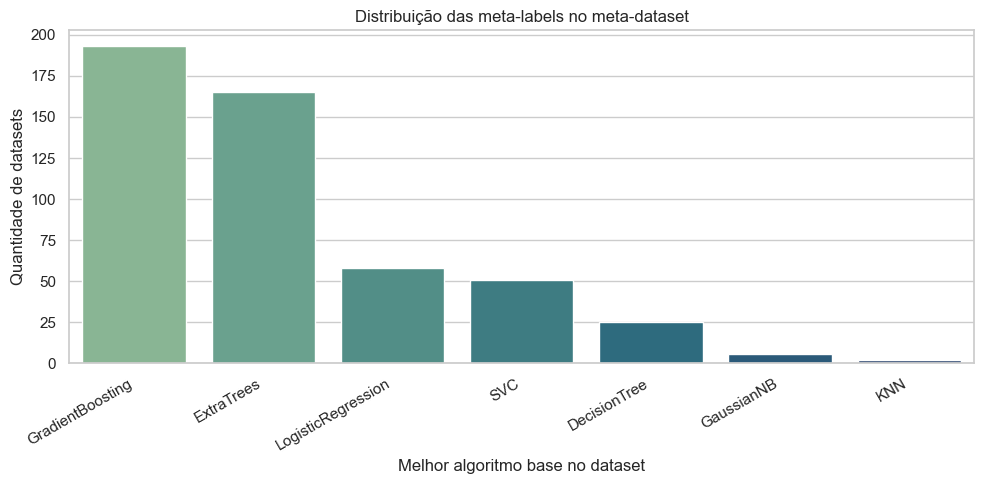

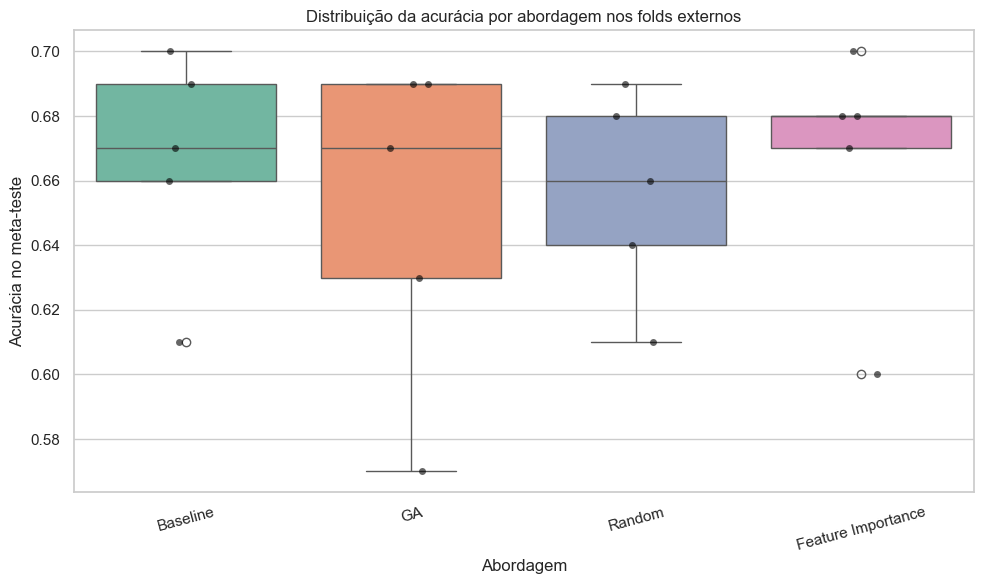

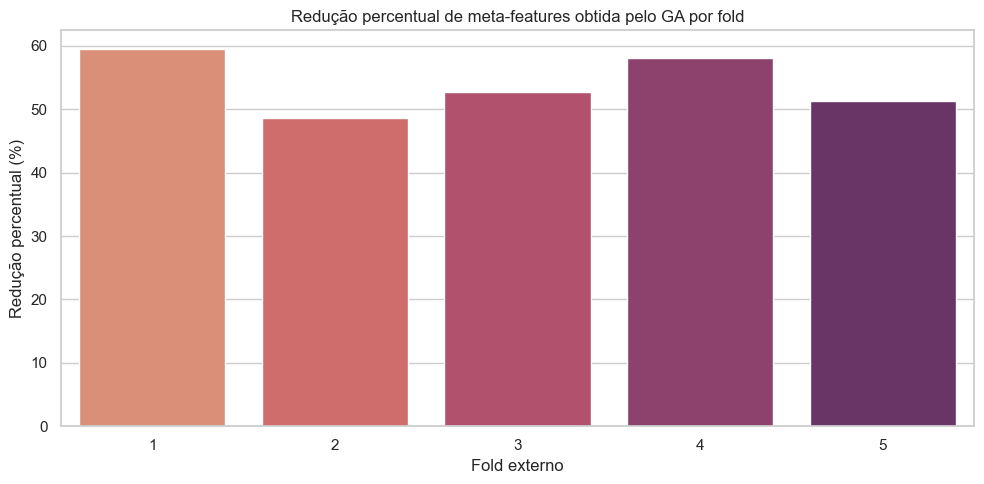

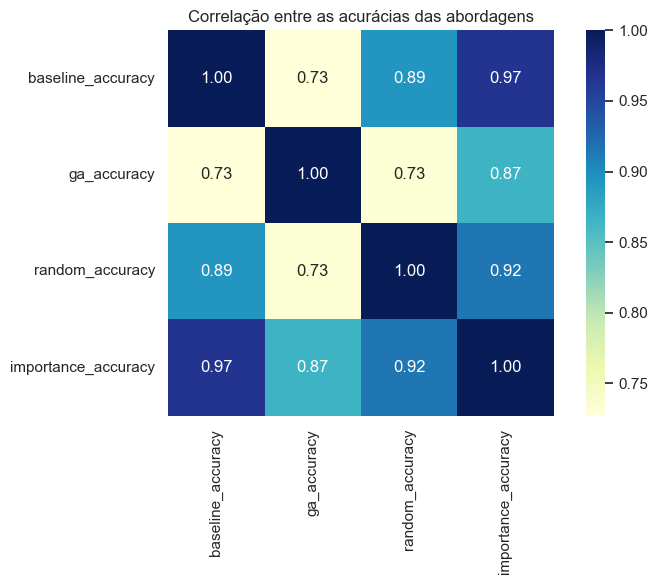

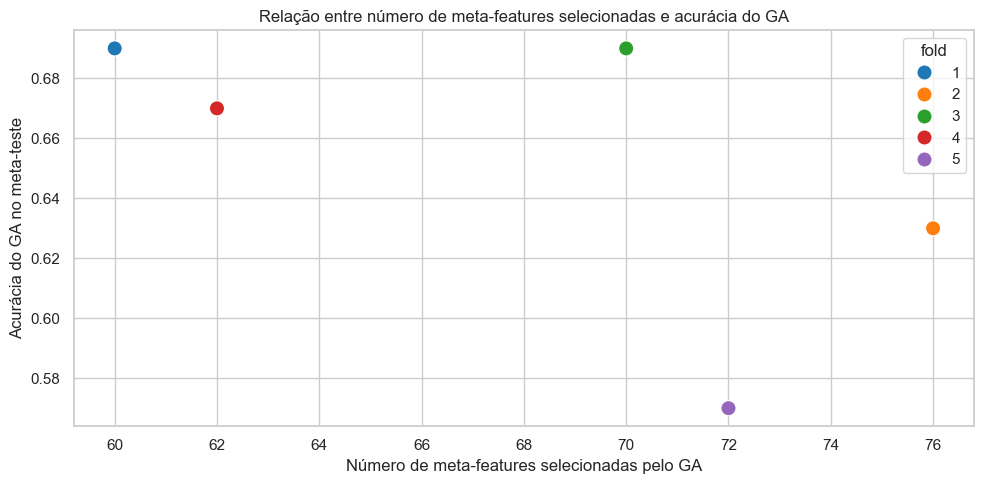

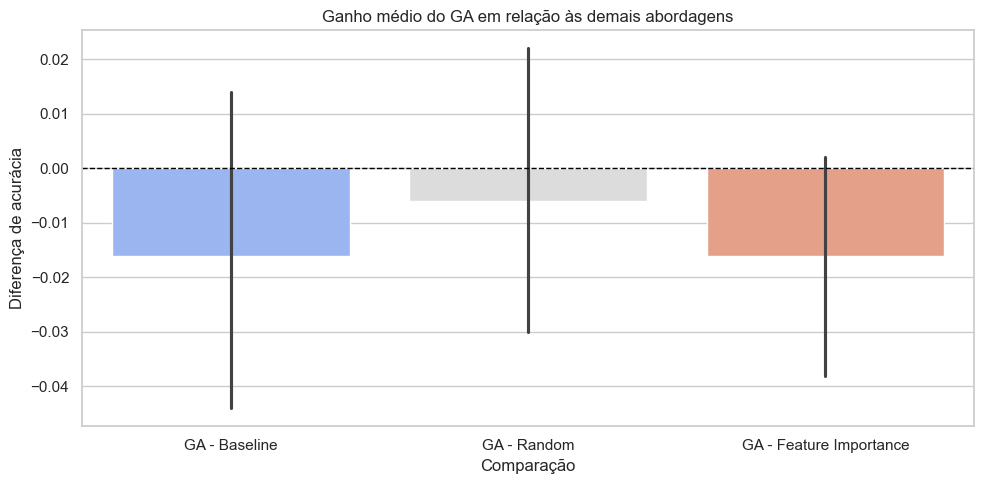

In [46]:
# Prepara tabelas auxiliares para visualizações mais informativas.
meta_label_counts = pd.Series(meta_y, name='meta_label').value_counts().reset_index()
meta_label_counts.columns = ['meta_label', 'count']

performance_long_df = results_df.melt(
    id_vars=['fold'],
    value_vars=['baseline_accuracy', 'ga_accuracy', 'random_accuracy', 'importance_accuracy'],
    var_name='approach',
    value_name='accuracy'
)
performance_long_df['approach'] = performance_long_df['approach'].map({
    'baseline_accuracy': 'Baseline',
    'ga_accuracy': 'GA',
    'random_accuracy': 'Random',
    'importance_accuracy': 'Feature Importance'
})

results_corr = results_df[['baseline_accuracy', 'ga_accuracy', 'random_accuracy', 'importance_accuracy']].corr()

plt.figure(figsize=(10, 5))
sns.barplot(data=meta_label_counts, x='meta_label', y='count', palette='crest')
plt.title('Distribuição das meta-labels no meta-dataset')
plt.xlabel('Melhor algoritmo base no dataset')
plt.ylabel('Quantidade de datasets')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
sns.boxplot(data=performance_long_df, x='approach', y='accuracy', palette='Set2')
sns.stripplot(data=performance_long_df, x='approach', y='accuracy', color='black', alpha=0.6, size=5)
plt.title('Distribuição da acurácia por abordagem nos folds externos')
plt.xlabel('Abordagem')
plt.ylabel('Acurácia no meta-teste')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
sns.barplot(data=results_df, x='fold', y='reduction_pct', palette='flare')
plt.title('Redução percentual de meta-features obtida pelo GA por fold')
plt.xlabel('Fold externo')
plt.ylabel('Redução percentual (%)')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
sns.heatmap(results_corr, annot=True, cmap='YlGnBu', fmt='.2f', square=True)
plt.title('Correlação entre as acurácias das abordagens')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
sns.scatterplot(data=results_df, x='n_features_ga', y='ga_accuracy', hue='fold', palette='tab10', s=120)
plt.title('Relação entre número de meta-features selecionadas e acurácia do GA')
plt.xlabel('Número de meta-features selecionadas pelo GA')
plt.ylabel('Acurácia do GA no meta-teste')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
gain_df = results_df[['fold', 'ga_accuracy', 'baseline_accuracy', 'random_accuracy', 'importance_accuracy']].copy()
gain_df['ga_minus_baseline'] = gain_df['ga_accuracy'] - gain_df['baseline_accuracy']
gain_df['ga_minus_random'] = gain_df['ga_accuracy'] - gain_df['random_accuracy']
gain_df['ga_minus_importance'] = gain_df['ga_accuracy'] - gain_df['importance_accuracy']
gain_long_df = gain_df.melt(
    id_vars=['fold'],
    value_vars=['ga_minus_baseline', 'ga_minus_random', 'ga_minus_importance'],
    var_name='comparison',
    value_name='gain'
)
gain_long_df['comparison'] = gain_long_df['comparison'].map({
    'ga_minus_baseline': 'GA - Baseline',
    'ga_minus_random': 'GA - Random',
    'ga_minus_importance': 'GA - Feature Importance'
})
sns.barplot(data=gain_long_df, x='comparison', y='gain', palette='coolwarm')
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.title('Ganho médio do GA em relação às demais abordagens')
plt.xlabel('Comparação')
plt.ylabel('Diferença de acurácia')
plt.tight_layout()
plt.show()


## 18. Análise interpretativa dos resultados

Este bloco organiza a leitura dos resultados em pares de **análise** e **gráfico relacionado**, facilitando a escrita do relatório e a interpretação final do experimento.

### Análise 1. Comparação geral entre as abordagens

A primeira pergunta do projeto é se a seleção heurística por GA melhora a acurácia final do sistema de meta-learning. Para isso, comparamos a acurácia média no meta-teste entre `Baseline`, `GA`, `Random Feature Selection` e `Feature Importance`.

Se o `GA` superar ou empatar com o `Baseline` usando menos meta-features, isso indica um bom trade-off. Se ele ficar abaixo das abordagens mais simples, a conclusão é que a busca heurística reduziu dimensionalidade, mas não trouxe ganho final de desempenho.

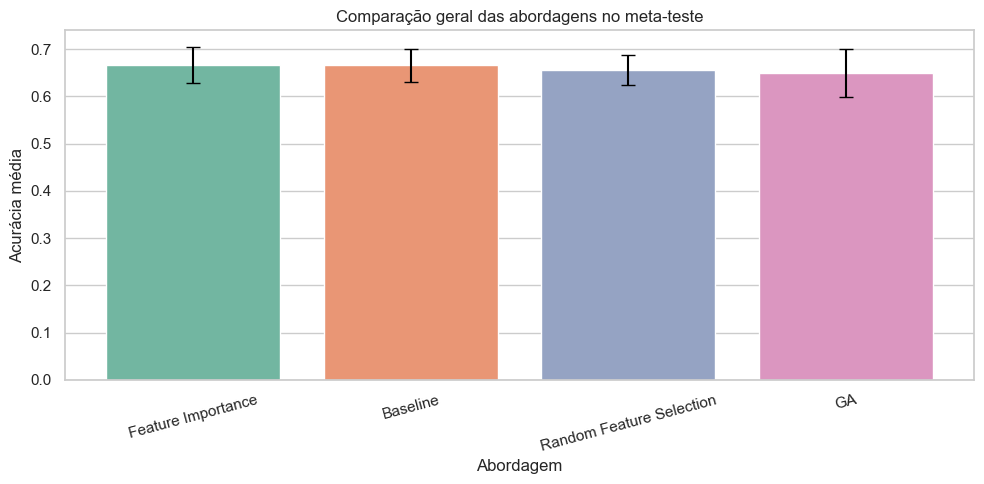

,Abordagem,Acurácia média no meta-teste,Desvio padrão
0,Feature Importance,0.666,0.038471
1,Baseline,0.666,0.035071
2,Random Feature Selection,0.656,0.032094
3,GA,0.650,0.050990


In [ ]:
plt.figure(figsize=(10, 5))
plot_df = summary_table.copy()
sns.barplot(data=plot_df, x='Abordagem', y='Acurácia média no meta-teste', palette='Set2')
plt.errorbar(x=np.arange(len(plot_df)), y=plot_df['Acurácia média no meta-teste'], yerr=plot_df['Desvio padrão'], fmt='none', ecolor='black', capsize=5)
plt.title('Comparação geral das abordagens no meta-teste')
plt.xlabel('Abordagem')
plt.ylabel('Acurácia média')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()
display(summary_table)


### Análise 2. O GA conseguiu reduzir a dimensionalidade?

Mesmo que o `GA` não seja a melhor abordagem em acurácia, ele ainda pode ser valioso se reduzir bastante o número de meta-features. Aqui analisamos quantas features existiam após o pré-processamento e quantas foram mantidas pela solução evolutiva em cada fold.

Se a redução for alta e a perda de desempenho for pequena, ainda há um resultado interessante em termos de compactação do meta-dataset.

O GA reduziu em média 54.05% das meta-features, mantendo 68.00 de 148.00 atributos e removendo aproximadamente 80.00 meta-features por fold.


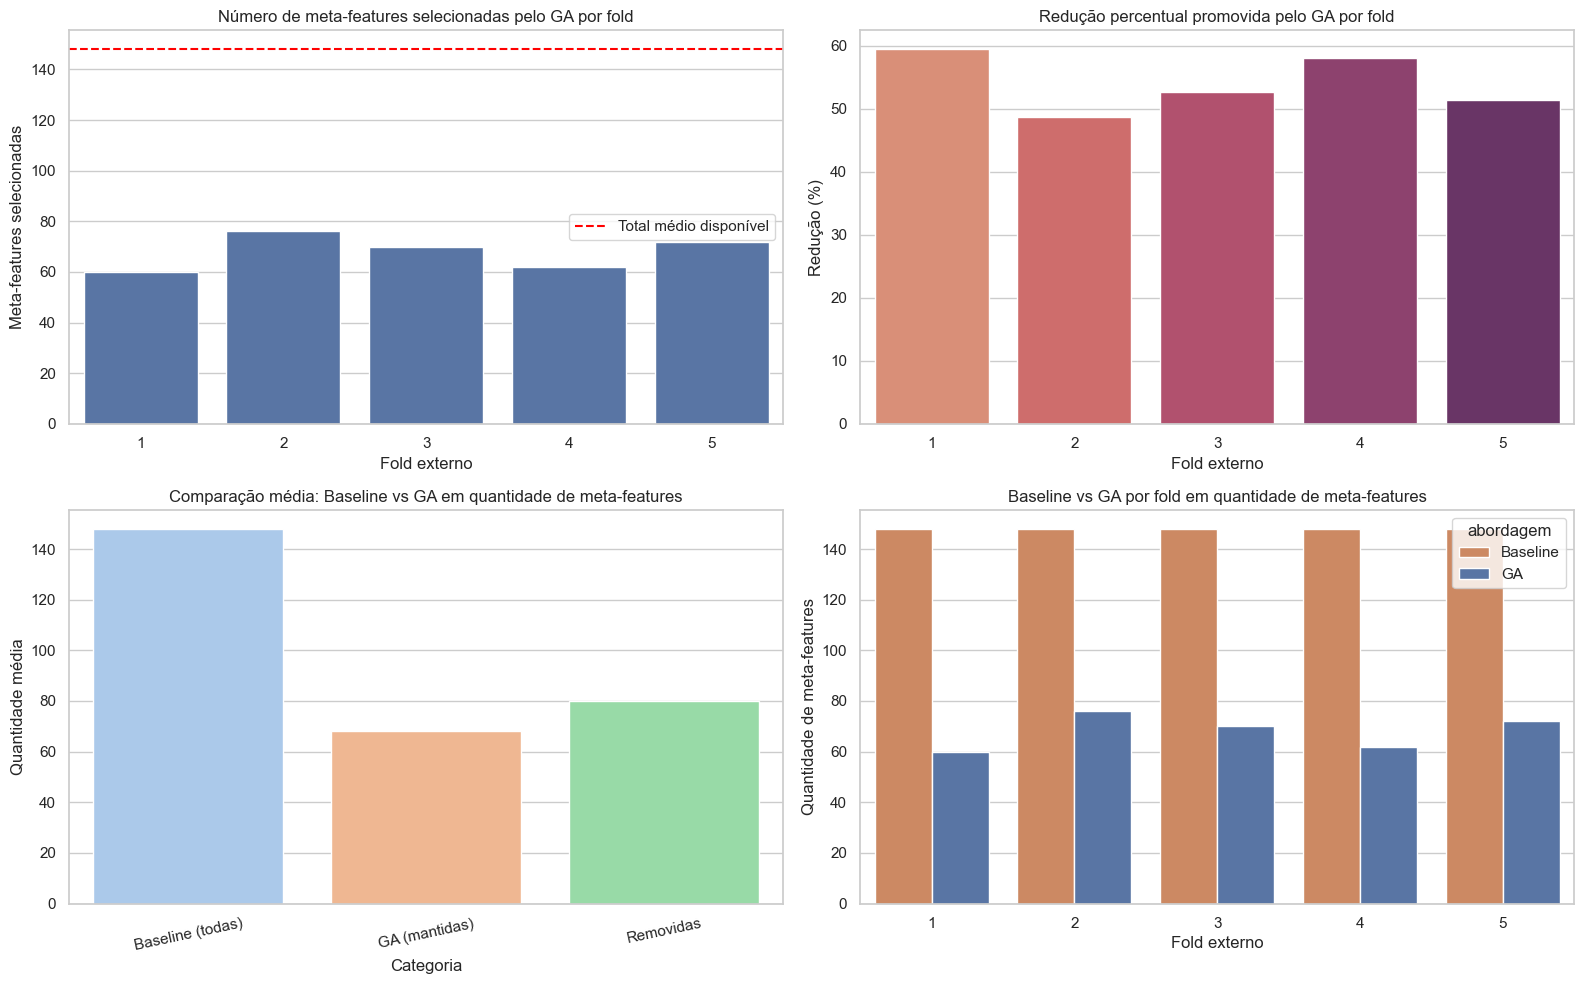

,fold,n_features_total,n_features_ga,reduction_pct
0,1,148,60,59.459459
1,2,148,76,48.648649
2,3,148,70,52.702703
3,4,148,62,58.108108
4,5,148,72,51.351351


In [60]:
avg_total_features = results_df['n_features_total'].mean()
avg_ga_features = results_df['n_features_ga'].mean()
avg_reduction_pct = results_df['reduction_pct'].mean()
avg_removed_features = avg_total_features - avg_ga_features

print(
    f'O GA reduziu em média {avg_reduction_pct:.2f}% das meta-features, '
    f'mantendo {avg_ga_features:.2f} de {avg_total_features:.2f} atributos e removendo '
    f'aproximadamente {avg_removed_features:.2f} meta-features por fold.'
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

mean_comparison_df = pd.DataFrame({
    'categoria': ['Baseline (todas)', 'GA (mantidas)', 'Removidas'],
    'quantidade_media': [avg_total_features, avg_ga_features, avg_removed_features]
})
sns.barplot(data=mean_comparison_df, x='categoria', y='quantidade_media', palette='pastel', ax=axes[0])
axes[0].set_title('Comparação média: Baseline vs GA em quantidade de meta-features')
axes[0].set_xlabel('Categoria')
axes[0].set_ylabel('Quantidade média')
axes[0].tick_params(axis='x', rotation=12)

baseline_vs_ga_by_fold = pd.DataFrame({
    'fold': results_df['fold'].tolist() * 2,
    'abordagem': ['Baseline'] * len(results_df) + ['GA'] * len(results_df),
    'n_meta_features': results_df['n_features_total'].tolist() + results_df['n_features_ga'].tolist()
})
sns.barplot(data=baseline_vs_ga_by_fold, x='fold', y='n_meta_features', hue='abordagem', palette=['#DD8452', '#4C72B0'], ax=axes[1])
axes[1].set_title('Baseline vs GA por fold em quantidade de meta-features')
axes[1].set_xlabel('Fold externo')
axes[1].set_ylabel('Quantidade de meta-features')

plt.tight_layout()
plt.show()
display(results_df[['fold', 'n_features_total', 'n_features_ga', 'reduction_pct']])


### Análise 2.1. O GA convergiu bem no primeiro fold?

Além do resultado final, é importante observar se o processo evolucionário melhorou o fitness ao longo das gerações. Uma curva de convergência ascendente e depois estável sugere que o GA encontrou soluções progressivamente melhores e depois estabilizou a busca.

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(np.arange(1, len(first_fold_ga_history) + 1), first_fold_ga_history, marker='o', linewidth=2)
plt.title('Curva de convergência do GA no primeiro fold externo')
plt.xlabel('Geração')
plt.ylabel('Fitness')
plt.tight_layout()
plt.show()


### Análise 3. O comportamento do GA foi estável entre os folds?

Uma média sozinha pode esconder instabilidade. Por isso, aqui observamos o desempenho do `GA` fold a fold e comparamos diretamente com `Baseline`, `Random` e `Feature Importance`.

Se o `GA` oscilar muito, isso indica menor robustez. Se competir de forma consistente, o resultado fica mais confiável.

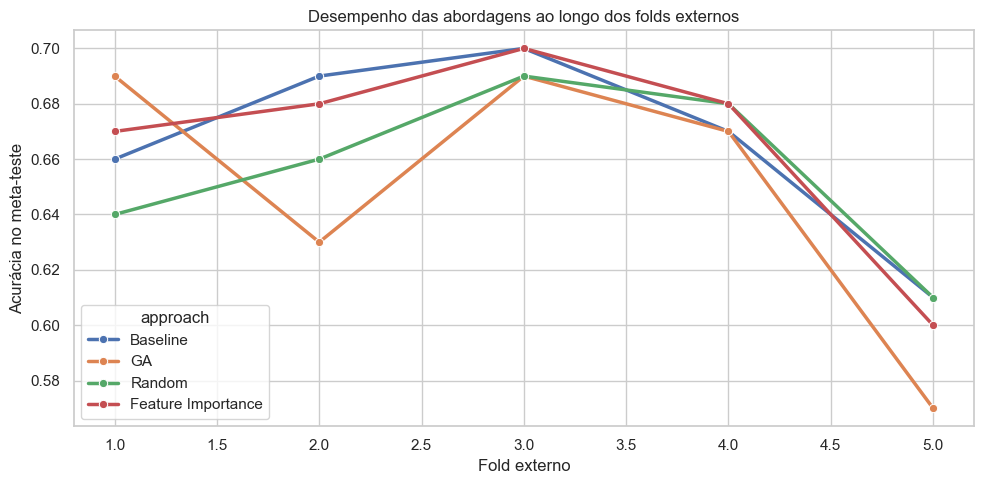

,fold,baseline_accuracy,ga_accuracy,random_accuracy,importance_accuracy
0,1,0.66,0.69,0.64,0.67
1,2,0.69,0.63,0.66,0.68
2,3,0.70,0.69,0.69,0.70
3,4,0.67,0.67,0.68,0.68
4,5,0.61,0.57,0.61,0.60


In [ ]:
comparison_by_fold = results_df[['fold', 'baseline_accuracy', 'ga_accuracy', 'random_accuracy', 'importance_accuracy']].copy()
comparison_by_fold = comparison_by_fold.melt(id_vars='fold', var_name='approach', value_name='accuracy')
comparison_by_fold['approach'] = comparison_by_fold['approach'].map({
    'baseline_accuracy': 'Baseline',
    'ga_accuracy': 'GA',
    'random_accuracy': 'Random',
    'importance_accuracy': 'Feature Importance'
})
plt.figure(figsize=(10, 5))
sns.lineplot(data=comparison_by_fold, x='fold', y='accuracy', hue='approach', marker='o', linewidth=2.5)
plt.title('Desempenho das abordagens ao longo dos folds externos')
plt.xlabel('Fold externo')
plt.ylabel('Acurácia no meta-teste')
plt.tight_layout()
plt.show()
display(results_df[['fold', 'baseline_accuracy', 'ga_accuracy', 'random_accuracy', 'importance_accuracy']])


### Análise 4. O ganho do GA compensou em relação às alternativas?

Aqui analisamos a diferença direta entre a acurácia do `GA` e a das demais abordagens. Esse tipo de gráfico ajuda a responder rapidamente se o ganho foi positivo ou negativo na maior parte dos folds.

Valores acima de zero favorecem o `GA`; valores abaixo de zero favorecem a abordagem comparada.

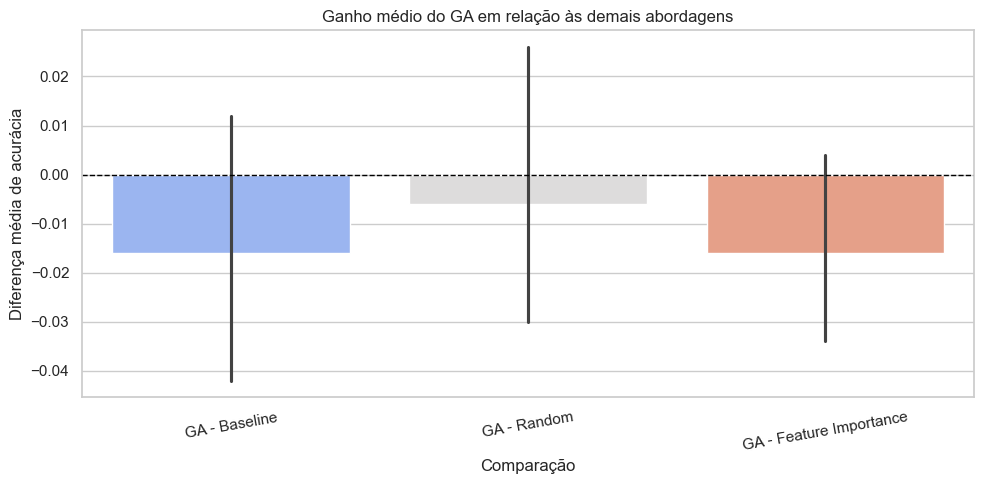

,comparison,gain
0,GA - Baseline,-0.016
1,GA - Feature Importance,-0.016
2,GA - Random,-0.006


In [ ]:
gain_df = results_df[['fold', 'ga_accuracy', 'baseline_accuracy', 'random_accuracy', 'importance_accuracy']].copy()
gain_df['GA - Baseline'] = gain_df['ga_accuracy'] - gain_df['baseline_accuracy']
gain_df['GA - Random'] = gain_df['ga_accuracy'] - gain_df['random_accuracy']
gain_df['GA - Feature Importance'] = gain_df['ga_accuracy'] - gain_df['importance_accuracy']
gain_long = gain_df[['fold', 'GA - Baseline', 'GA - Random', 'GA - Feature Importance']].melt(id_vars='fold', var_name='comparison', value_name='gain')
plt.figure(figsize=(10, 5))
sns.barplot(data=gain_long, x='comparison', y='gain', palette='coolwarm')
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.title('Ganho médio do GA em relação às demais abordagens')
plt.xlabel('Comparação')
plt.ylabel('Diferença média de acurácia')
plt.xticks(rotation=10)
plt.tight_layout()
plt.show()
display(gain_long.groupby('comparison', as_index=False)['gain'].mean())


### Análise 5. Quais algoritmos dominaram o meta-dataset?

A distribuição das meta-labels mostra quais algoritmos venceram com maior frequência no nível-base. Isso ajuda a entender o nível de balanceamento do meta-problema e pode explicar parte do comportamento do meta-modelo.

Se poucas classes dominarem muitos datasets, o meta-problema fica mais desbalanceado.

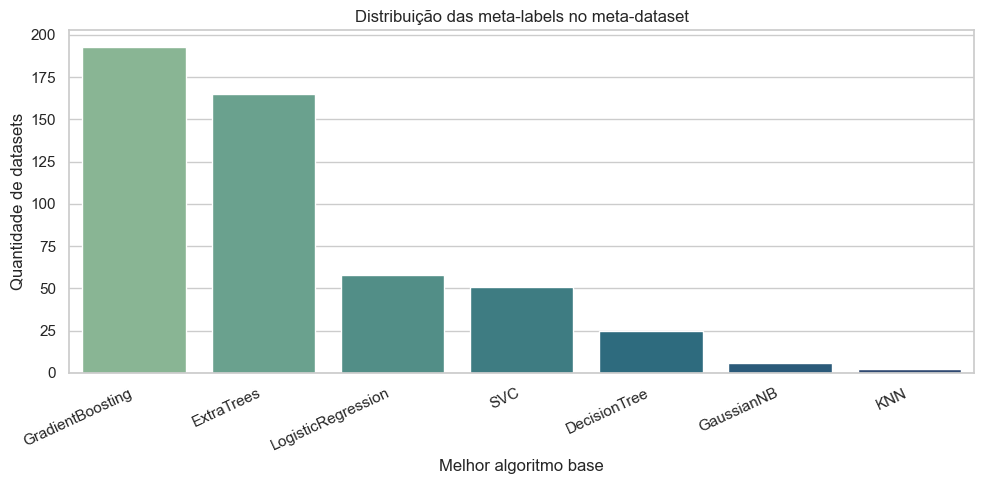

,meta_label,count
0,GradientBoosting,193
1,ExtraTrees,165
2,LogisticRegression,58
3,SVC,51
4,DecisionTree,25
5,GaussianNB,6
6,KNN,2


In [ ]:
meta_label_distribution = pd.Series(meta_y, name='meta_label').value_counts().reset_index()
meta_label_distribution.columns = ['meta_label', 'count']
plt.figure(figsize=(10, 5))
sns.barplot(data=meta_label_distribution, x='meta_label', y='count', palette='crest')
plt.title('Distribuição das meta-labels no meta-dataset')
plt.xlabel('Melhor algoritmo base')
plt.ylabel('Quantidade de datasets')
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.show()
display(meta_label_distribution)


### Análise 6. Quais meta-features o GA mais preferiu?

Por fim, analisamos a recorrência das meta-features nas soluções do GA. Essa visualização é útil para a discussão qualitativa do trabalho, pois ajuda a identificar quais atributos descritivos parecem mais relevantes para prever o melhor algoritmo base.

Se algumas meta-features aparecem repetidamente, isso sugere que elas carregam informação mais estável no meta-problema.

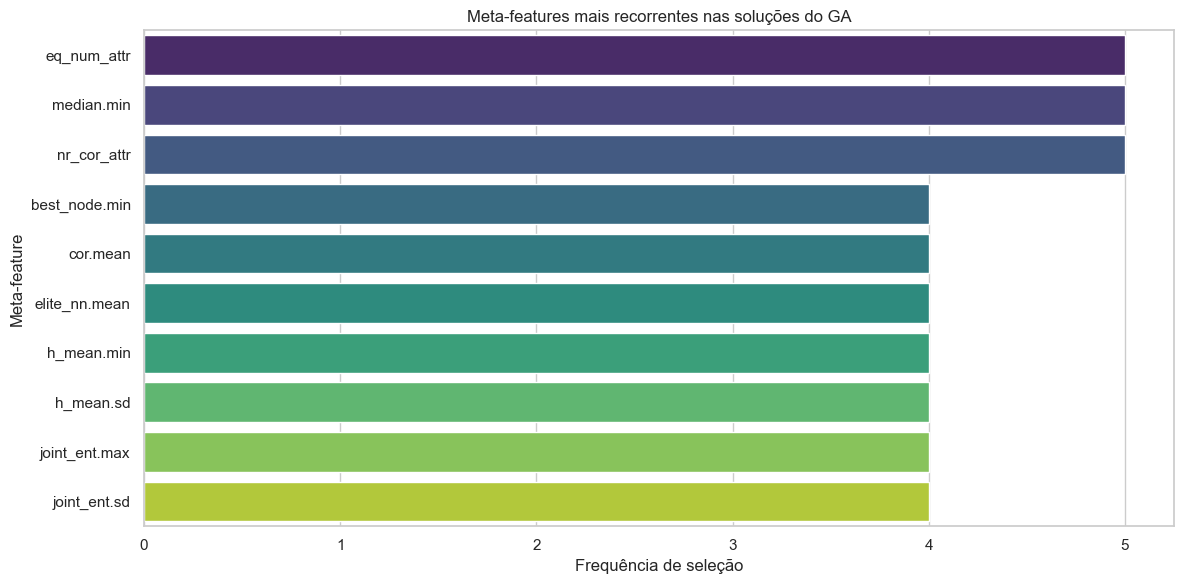

,meta_feature,frequencia
0,eq_num_attr,5
1,median.min,5
2,nr_cor_attr,5
3,best_node.min,4
4,cor.mean,4
5,elite_nn.mean,4
6,h_mean.min,4
7,h_mean.sd,4
8,joint_ent.max,4
9,joint_ent.sd,4


In [ ]:
plt.figure(figsize=(12, 6))
sns.barplot(data=top_features_df, x='frequencia', y='meta_feature', palette='viridis')
plt.title('Meta-features mais recorrentes nas soluções do GA')
plt.xlabel('Frequência de seleção')
plt.ylabel('Meta-feature')
plt.tight_layout()
plt.show()
display(top_features_df)
